In [1]:
!pip install -q torch folium
import os, math, pickle, warnings
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import folium
from folium.plugins import HeatMap
from sklearn.manifold import MDS
from IPython.display import display, HTML
warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [2]:
from google.colab import drive
drive.mount("/content/drive")

DATA_DIR = "/content/drive/MyDrive/LSTGAN_Data"
RESULTS_DIR = "/content/drive/MyDrive/LSTGAN_Data/results"
CKPT_PATH = os.path.join(RESULTS_DIR, "best_lstgan.pt")

print(f"Data directory: {DATA_DIR}")
print(f"Checkpoint: {CKPT_PATH}")

import os
required_files = [
    os.path.join(RESULTS_DIR, "best_lstgan.pt"),
    os.path.join(RESULTS_DIR, "train_5min.pkl"),
    os.path.join(RESULTS_DIR, "test_5min.pkl"),
    os.path.join(RESULTS_DIR, "val_5min.pkl"),
    os.path.join(DATA_DIR, "adj_mx_bay.pkl"),
]
missing = [f for f in required_files if not os.path.exists(f)]
if missing:
    print("\nMissing files:")
    for f in missing: print(f"  - {f}")
    print("\nPlease upload these files to your Google Drive!")
else:
    print("\nAll required files found!")

Mounted at /content/drive
Data directory: /content/drive/MyDrive/LSTGAN_Data
Checkpoint: /content/drive/MyDrive/LSTGAN_Data/results/best_lstgan.pt

All required files found!


In [3]:
NUM_SENSORS = 325
WEEKLY_WINDOW = 2016
DAILY_WINDOW = 288
HOURLY_WINDOW = 12
FORECAST_HORIZON = 12

D_MODEL = 48
SPATIAL_EMBED_DIM = 16
WEEKLY_IN_CHANNELS = 3
WEEKLY_OUT_CHANNELS = 16
DAILY_IN_CHANNELS = 3
DAILY_OUT_CHANNELS = 8
HOURLY_IN_CHANNELS = 1
GLOBAL_SPATIAL_CHANNELS = 16
LOCAL_SPATIAL_CHANNELS = 8
CHEBYSHEV_K = 5
GLOBAL_ATTN_HEADS = 4
GLOBAL_ATTN_LAYERS = 1
DECODER_HEADS = 6
DECODER_LAYERS = 1
WEEKLY_STRIDE_1 = 14
WEEKLY_STRIDE_2 = 12
DAILY_STRIDE_1  = 4
DAILY_STRIDE_2 = 6

print('Config loaded')

Config loaded


In [4]:
class TemporalEncoder(nn.Module):
    def __init__(s,ic,oc,s1,s2):
        super().__init__(); m=max((ic+oc)//2,8)
        s.c1a=nn.Conv1d(ic,m,3,padding=1); s.c1b=nn.Conv1d(m,m,s1,stride=s1)
        s.bn1=nn.BatchNorm1d(m); s.c2a=nn.Conv1d(m,oc,3,padding=1)
        s.c2b=nn.Conv1d(oc,oc,s2,stride=s2); s.bn2=nn.BatchNorm1d(oc)
    def forward(s,x):
        B,T,N,C=x.shape; x=x.permute(0,2,3,1).reshape(B*N,C,T)
        x=F.relu(s.bn1(s.c1b(F.relu(s.c1a(x))))); x=s.bn2(s.c2b(F.relu(s.c2a(x))))
        _,Co,To=x.shape; return x.reshape(B,N,Co,To).permute(0,3,1,2)

class SpatialEmbedding(nn.Module):
    def __init__(s,ic=1,oc=16): super().__init__(); s.conv=nn.Conv1d(ic,oc,1); s.bn=nn.BatchNorm1d(oc)
    def forward(s,x):
        B,T,N,C=x.shape; x=x.reshape(B*T,N,C).permute(0,2,1); return s.bn(s.conv(x)).permute(0,2,1).reshape(B,T,N,-1)

class GlobalSpatialEncoder(nn.Module):
    def __init__(s,d=16,h=4,nl=1,oc=16):
        super().__init__()
        s.layers=nn.ModuleList()
        for _ in range(nl): s.layers.append(nn.ModuleDict({'attn':nn.MultiheadAttention(d,h,batch_first=True,dropout=0.1),'n1':nn.LayerNorm(d),'n2':nn.LayerNorm(d),'ffn':nn.Sequential(nn.Linear(d,d*4),nn.GELU(),nn.Dropout(0.1),nn.Linear(d*4,d))}))
        s.proj=nn.Linear(d,oc) if d!=oc else nn.Identity()
    def forward(s,x):
        B,T,N,C=x.shape; x=x.reshape(B*T,N,C)
        for l in s.layers: a,_=l['attn'](x,x,x); x=l['n1'](x+a); x=l['n2'](x+l['ffn'](x))
        return s.proj(x).reshape(B,T,N,-1)

class ManualChebConv(nn.Module):
    def __init__(s,ic,oc,K=5):
        super().__init__()
        s.K=K; s.weights=nn.ParameterList([nn.Parameter(torch.empty(ic,oc)) for _ in range(K)])
        s.bias=nn.Parameter(torch.zeros(oc))
        for w in s.weights: nn.init.xavier_uniform_(w)
    def forward(s,x,L):
        Z0,Z1=x,L@x; o=Z0@s.weights[0]
        if s.K>1: o=o+Z1@s.weights[1]
        for k in range(2,s.K): Zk=2*L@Z1-Z0; o=o+Zk@s.weights[k]; Z0,Z1=Z1,Zk
        return o+s.bias

class LocalSpatialEncoder(nn.Module):
    def __init__(s,ic=16,oc=8,K=5):
        super().__init__(); s.cheb=ManualChebConv(ic,oc,K);
        s.register_buffer('L_scaled', torch.zeros(325, 325))
    def set_graph(s,A):
        Di=np.diag(1./np.sqrt(np.maximum(A.sum(1),1e-8))); L=np.eye(A.shape[0])-Di@A@Di
        e=np.linalg.eigvalsh(L); s.L_scaled.copy_(torch.FloatTensor(2*L/(e[-1]+1e-8)-np.eye(A.shape[0])))
    def forward(s,x):
        B,T,N,C=x.shape; return s.cheb(x.reshape(B*T,N,C),s.L_scaled).reshape(B,T,N,-1)

class TimeEncoder(nn.Module):
    def __init__(s,d=48,td=295):
        super().__init__()
        s.mlp=nn.Sequential(nn.Linear(td,d*2),nn.Linear(d*2,d*2),nn.ReLU(),nn.Linear(d*2,d)); s.norm=nn.LayerNorm(d)
    def forward(s,ste,ti):
        vt=s.mlp(torch.cat([F.one_hot(ti[:,0].long(),7).float(),F.one_hot(ti[:,1].long(),288).float()],-1))
        vt = vt[:,None,None,:].expand_as(ste)
        return s.norm(ste+vt)

class PositionalEncoding(nn.Module):
    def __init__(s,d,ml=500):
        super().__init__()
        pe=torch.zeros(ml,d);p=torch.arange(ml).unsqueeze(1).float();dv=torch.exp(torch.arange(0,d,2).float()*(-math.log(10000.)/d))
        pe[:,0::2]=torch.sin(p*dv);pe[:,1::2]=torch.cos(p*dv);s.register_buffer('pe',pe.unsqueeze(0))
    def forward(s,x): return x+s.pe[:,:x.size(1),:]

class TemporalDecoder(nn.Module):
    def __init__(s,d=48,h=6,nl=1,H=3):
        super().__init__()
        s.H=H;s.pe=PositionalEncoding(d);s.enc_layers=nn.ModuleList();s.dec_layers=nn.ModuleList()
        for _ in range(nl):
            s.enc_layers.append(nn.ModuleDict({'attn':nn.MultiheadAttention(d,h,batch_first=True,dropout=0.1),'n1':nn.LayerNorm(d),'n2':nn.LayerNorm(d),'ffn':nn.Sequential(nn.Linear(d,d*4),nn.GELU(),nn.Dropout(0.1),nn.Linear(d*4,d))}))
            s.dec_layers.append(nn.ModuleDict({'attn':nn.MultiheadAttention(d,h,batch_first=True,dropout=0.1),'n1':nn.LayerNorm(d),'n2':nn.LayerNorm(d),'ffn':nn.Sequential(nn.Linear(d,d*4),nn.GELU(),nn.Dropout(0.1),nn.Linear(d*4,d))}))
        s.fq=nn.Parameter(torch.randn(1,H,d)*0.02);s.out_proj=nn.Linear(d,1)
    def forward(s,ste):
        B,T,N,d=ste.shape;x=ste.permute(0,2,1,3).reshape(B*N,T,d);x=s.pe(x)
        for l in s.enc_layers: a,_=l['attn'](x,x,x);x=l['n1'](x+a);x=l['n2'](x+l['ffn'](x))
        q=s.fq.expand(B*N,-1,-1)
        for l in s.dec_layers: a,_=l['attn'](q,x,x);q=l['n1'](q+a);q=l['n2'](q+l['ffn'](q))
        return s.out_proj(q).reshape(B,N,s.H,1).permute(0,2,1,3)

class LSTGAN(nn.Module):
    def __init__(s):
        super().__init__()
        s.weekly_enc=TemporalEncoder(3,16,WEEKLY_STRIDE_1,WEEKLY_STRIDE_2)
        s.daily_enc=TemporalEncoder(3,8,DAILY_STRIDE_1,DAILY_STRIDE_2)
        s.sp_embed=SpatialEmbedding(1,16);s.global_enc=GlobalSpatialEncoder(16,4,1,16)
        s.local_enc=LocalSpatialEncoder(16,8,5)
        s.time_enc=TimeEncoder(48, td=295)
        s.decoder=TemporalDecoder(48, 6, 1, 12)
    def _mt(s,x,t):
        T=x.shape[1]
        if T==t:return x
        if T>t:return x[:,:t]
        B,T,N,C=x.shape;return F.interpolate(x.permute(0,3,2,1).reshape(B*C*N,1,T),size=t,mode='nearest').reshape(B,C,N,t).permute(0,3,2,1)
    def forward(s,Xw,Xd,Xh,ti,ei=None,ew=None):
        W=s.weekly_enc(Xw);D=s.daily_enc(Xd);Xe=s.sp_embed(Xh);Sa=s.global_enc(Xe);Gc=s.local_enc(Xe);t=Xh.shape[1]
        return s.decoder(s.time_enc(torch.cat([s._mt(W,t),s._mt(D,t),Sa,Gc],-1),ti))

print('Model ready.')

Model ready.


In [5]:
import sys
if 'numpy._core' not in sys.modules:
    import numpy.core as _core
    sys.modules['numpy._core'] = _core
    sys.modules['numpy._core.numeric'] = _core.numeric

train_df = pd.read_pickle(os.path.join(RESULTS_DIR, 'train_5min.pkl'))
test_df  = pd.read_pickle(os.path.join(RESULTS_DIR, 'test_5min.pkl'))
val_df   = pd.read_pickle(os.path.join(RESULTS_DIR, 'val_5min.pkl'))

if hasattr(train_df.index, 'freq'):
    train_df.index.freq = None
if hasattr(test_df.index, 'freq'):
    test_df.index.freq = None
if hasattr(val_df.index, 'freq'):
    val_df.index.freq = None

all_df   = pd.concat([train_df, val_df, test_df])

with open(os.path.join(DATA_DIR, 'adj_mx_bay.pkl'),'rb') as f:
    adj = pickle.load(f, encoding='latin1')
    if isinstance(adj,(tuple,list)):
        adj = adj[2] if len(adj)>=3 else adj[-1]
    adj = adj.astype(np.float32)

ckpt = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)
train_mean = ckpt['mean']
train_std = ckpt['std']

all_speed = ((all_df.values - train_mean) / (train_std + 1e-8)).astype(np.float32)

all_dow = all_df.index.dayofweek.values
all_tod = (all_df.index.hour * 12 + all_df.index.minute // 5).values
all_hod = all_df.index.hour.values
raw_data = all_df.values

print(f'Data shape: {all_df.shape}')
print(f'Date range: {all_df.index[0]} to {all_df.index[-1]}')

edge_index = torch.LongTensor(np.stack(np.nonzero(adj))).to(DEVICE)
edge_weight = torch.FloatTensor(adj[adj!=0]).to(DEVICE)

model = LSTGAN().to(DEVICE)
model.local_enc.set_graph(adj)
model.load_state_dict(ckpt['model'])
model.eval()
print(f'Model loaded (epoch {ckpt["epoch"]}, val_mae={ckpt.get("val_mae", "N/A")})')

Data shape: (52116, 325)
Date range: 2017-01-01 00:00:00 to 2017-06-30 23:55:00
Model loaded (epoch 50, val_mae=1.5933863246560696)


In [6]:
print('Generating sensor positions using MDS on graph distances...')

A = adj.copy()
A[A == 0] = 1e-6
dist_matrix = np.zeros((NUM_SENSORS, NUM_SENSORS))

for i in range(NUM_SENSORS):
    for j in range(NUM_SENSORS):
        if adj[i,j] > 0.01:
            dist_matrix[i,j] = 1.0 / adj[i,j]
        else:
            dist_matrix[i,j] = 10.0

dist_matrix = (dist_matrix + dist_matrix.T) / 2
np.fill_diagonal(dist_matrix, 0)

mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, n_init=4, max_iter=300)
coords_2d = mds.fit_transform(dist_matrix)

lat_min, lat_max = 37.25, 37.85
lng_min, lng_max = -122.45, -121.80

coords_norm = (coords_2d - coords_2d.min(0)) / (coords_2d.max(0) - coords_2d.min(0) + 1e-8)
lats = lat_min + coords_norm[:, 0] * (lat_max - lat_min)
lngs = lng_min + coords_norm[:, 1] * (lng_max - lng_min)

print(f'Generated coordinates for {NUM_SENSORS} sensors')
print(f'  Lat range: [{lats.min():.4f}, {lats.max():.4f}]')
print(f'  Lng range: [{lngs.min():.4f}, {lngs.max():.4f}]')

Generating sensor positions using MDS on graph distances...
Generated coordinates for 325 sensors
  Lat range: [37.2500, 37.8500]
  Lng range: [-122.4500, -121.8000]


In [7]:
DAYS = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
def predict_all_sensors(day_of_week, hour):

    matches = [t for t in range(WEEKLY_WINDOW, len(all_df)-FORECAST_HORIZON)
               if all_dow[t]==day_of_week and all_hod[t]==hour]
    if not matches:
        return None

    n = min(5, len(matches))
    indices = np.random.choice(matches, n, replace=False)
    preds = []
    for t in indices:
        N = NUM_SENSORS

        sp_w = all_speed[t-WEEKLY_WINDOW:t]
        dw = (all_dow[t-WEEKLY_WINDOW:t] / 6.).astype(np.float32)
        tw = (all_tod[t-WEEKLY_WINDOW:t] / 287.).astype(np.float32)
        X_weekly = torch.from_numpy(
            np.stack([sp_w, np.tile(dw[:,None],(1,N)), np.tile(tw[:,None],(1,N))], -1)
        ).unsqueeze(0).to(DEVICE)

        sp_d = all_speed[t-DAILY_WINDOW:t]
        dd = (all_dow[t-DAILY_WINDOW:t] / 6.).astype(np.float32)
        td = (all_tod[t-DAILY_WINDOW:t] / 287.).astype(np.float32)
        X_daily = torch.from_numpy(
            np.stack([sp_d, np.tile(dd[:,None],(1,N)), np.tile(td[:,None],(1,N))], -1)
        ).unsqueeze(0).to(DEVICE)

        X_hourly = torch.from_numpy(all_speed[t-HOURLY_WINDOW:t][:,:,None]).unsqueeze(0).to(DEVICE)

        time_info = torch.tensor([[all_dow[t], all_tod[t]]]).to(DEVICE)

        with torch.no_grad():
            pred = model(X_weekly, X_daily, X_hourly, time_info, edge_index, edge_weight)
            preds.append((pred.cpu().numpy() * train_std + train_mean)[0, :, :, 0])
    return np.mean(preds, axis=0)  # (12, 325)
print('Prediction function ready')

Prediction function ready


In [ ]:
QUERY_DAY  = 0    # 0=Monday, 1=Tuesday, ..., 6=Sunday
QUERY_HOUR = 8    # 8 = 8 AM (rush hour)
HORIZON    = 0    # 0=+1h, 1=+2h, 2=+3h

print(f' Predicting traffic for {DAYS[QUERY_DAY]} at {QUERY_HOUR:02d}:00 (+{HORIZON+1}h ahead)...')
pred_speeds = predict_all_sensors(QUERY_DAY, QUERY_HOUR)
speeds = pred_speeds[HORIZON]  # (325,) predicted speeds

def speed_to_color(speed):
    if speed >= 55: return '#00b894'    # Green - Free Flow
    elif speed >= 45: return '#55efc4'  # Light green
    elif speed >= 35: return '#fdcb6e'  # Yellow - Moderate
    elif speed >= 25: return '#e17055'  # Orange - Heavy
    elif speed >= 15: return '#d63031'  # Red - Very Heavy
    else: return '#6c5ce7'             # Purple - Severe

def speed_to_level(speed):
    if speed >= 50: return '🟢 Free Flow'
    elif speed >= 35: return '🟡 Moderate'
    elif speed >= 20: return '🔴 Heavy'
    else: return '⛔ Severe'

center_lat = np.mean(lats)
center_lng = np.mean(lngs)
m = folium.Map(location=[center_lat, center_lng], zoom_start=11,
               tiles='CartoDB dark_matter')  # Dark theme looks great


title_html = f'''
<div style="position:fixed; top:10px; left:50%; transform:translateX(-50%); z-index:9999;
     background:rgba(0,0,0,0.8); padding:12px 24px; border-radius:10px; color:white; font-size:16px;">
  🚦 <b>LSTGAN Traffic Forecast</b> — {DAYS[QUERY_DAY]} {QUERY_HOUR:02d}:00 (+{HORIZON+1}h)
</div>
'''
m.get_root().html.add_child(folium.Element(title_html))

legend_html = '''
<div style="position:fixed; bottom:30px; right:20px; z-index:9999;
     background:rgba(0,0,0,0.85); padding:15px; border-radius:10px; color:white; font-size:13px;">
  <b>Speed Legend</b><br>
  <span style="color:#00b894">●</span> &gt;55 mph — Free Flow<br>
  <span style="color:#55efc4">●</span> 45-55 — Light<br>
  <span style="color:#fdcb6e">●</span> 35-45 — Moderate<br>
  <span style="color:#e17055">●</span> 25-35 — Heavy<br>
  <span style="color:#d63031">●</span> 15-25 — Very Heavy<br>
  <span style="color:#6c5ce7">●</span> &lt;15 — Severe<br>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

# Add sensors as colored circles
for i in range(NUM_SENSORS):
    speed = speeds[i]
    color = speed_to_color(speed)
    level = speed_to_level(speed)

    popup_text = f"""
    <div style='font-family:Arial; width:200px;'>
      <b style='font-size:14px;'>Sensor #{i}</b><br>
      <hr style='margin:5px 0;'>
      <b>Predicted Speed:</b> {speed:.1f} mph<br>
      <b>Status:</b> {level}<br>
      <b>Time:</b> {DAYS[QUERY_DAY]} {(QUERY_HOUR+HORIZON+1)%24:02d}:00<br>
      <hr style='margin:5px 0;'>
      <small>+1h: {pred_speeds[0,i]:.1f} mph<br>
      +2h: {pred_speeds[1,i]:.1f} mph<br>
      +3h: {pred_speeds[2,i]:.1f} mph</small>
    </div>
    """

    # Size based on congestion (bigger = more congested for visibility)
    radius = 8 if speed < 35 else 5

    folium.CircleMarker(
        location=[lats[i], lngs[i]],
        radius=radius,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.85,
        popup=folium.Popup(popup_text, max_width=250),
        tooltip=f'Sensor {i}: {speed:.0f} mph {level}',
    ).add_to(m)

# Draw edges between connected sensors (road network)
for i in range(NUM_SENSORS):
    for j in range(i+1, NUM_SENSORS):
        if adj[i,j] > 0.3:  # Only strong connections
            avg_speed = (speeds[i] + speeds[j]) / 2
            folium.PolyLine(
                [[lats[i],lngs[i]], [lats[j],lngs[j]]],
                color=speed_to_color(avg_speed),
                weight=1.5,
                opacity=0.3
            ).add_to(m)

# Stats
n_free = (speeds >= 50).sum()
n_mod  = ((speeds >= 35) & (speeds < 50)).sum()
n_heavy= ((speeds >= 20) & (speeds < 35)).sum()
n_sev  = (speeds < 20).sum()
print(f'\nTraffic Summary — {DAYS[QUERY_DAY]} {QUERY_HOUR:02d}:00 (+{HORIZON+1}h):')
print(f'  Free Flow: {n_free} sensors ({n_free/325*100:.0f}%)')
print(f'  Moderate:  {n_mod} sensors ({n_mod/325*100:.0f}%)')
print(f'  Heavy:     {n_heavy} sensors ({n_heavy/325*100:.0f}%)')
print(f'  Severe:    {n_sev} sensors ({n_sev/325*100:.0f}%)')
print(f'  Avg speed:    {speeds.mean():.1f} mph')
print(f'\nClick any sensor on the map to see details!')

m

 Predicting traffic for Monday at 08:00 (+1h ahead)...

Traffic Summary — Monday 08:00 (+1h):
  Free Flow: 213 sensors (66%)
  Moderate:  65 sensors (20%)
  Heavy:     40 sensors (12%)
  Severe:    7 sensors (2%)
  Avg speed:    52.4 mph

Click any sensor on the map to see details!


In [16]:
from google.colab import files

# Save the map object 'm' created in cell 36JmYJzIt3OM to a local file
map_filename = 'traffic_forecast_map.html'
m.save(map_filename)

# Trigger a browser download
files.download(map_filename)

print(f'Map saved as {map_filename} and download triggered.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Map saved as traffic_forecast_map.html and download triggered.


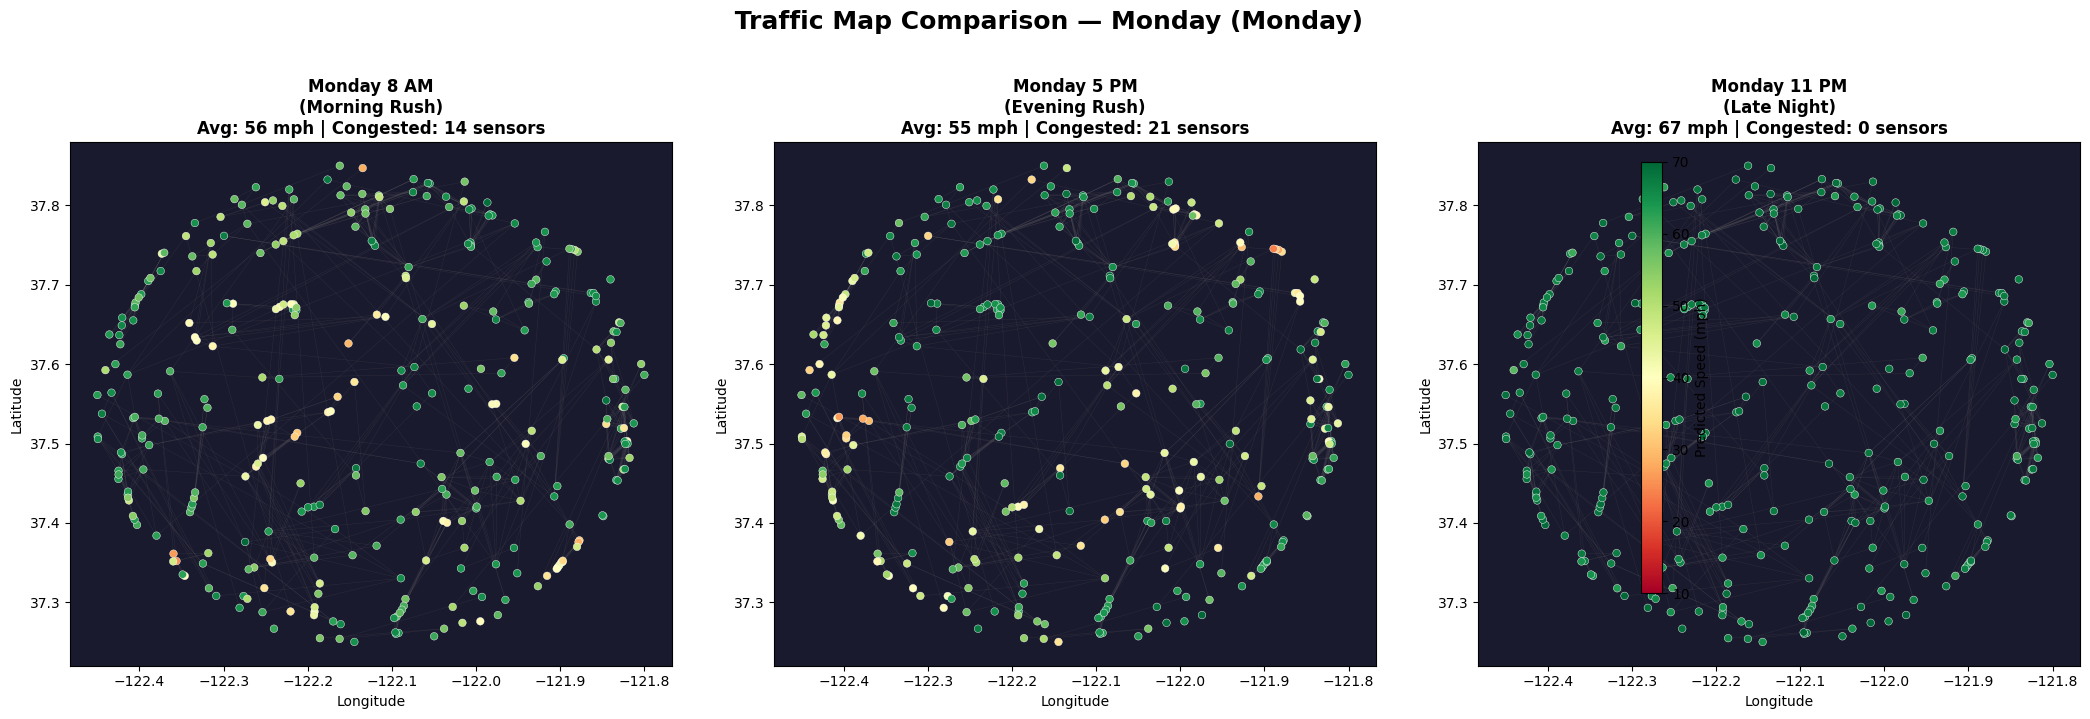

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle(f' Traffic Map Comparison — {DAYS[0]} (Monday)', fontsize=18, fontweight='bold', y=1.02)

scenarios = [
    (0, 8,  'Monday 8 AM\n(Morning Rush)'),
    (0, 17, 'Monday 5 PM\n(Evening Rush)'),
    (0, 23, 'Monday 11 PM\n(Late Night)'),
]

for ax, (day, hour, title) in zip(axes, scenarios):
    pred = predict_all_sensors(day, hour)
    spd = pred[0]

    colors = np.array([speed_to_color(s) for s in spd])

    scatter = ax.scatter(lngs, lats, c=spd, cmap='RdYlGn', vmin=10, vmax=70,
                        s=30, edgecolors='white', linewidth=0.3, zorder=5)

    for i in range(NUM_SENSORS):
        for j in range(i+1, NUM_SENSORS):
            if adj[i,j] > 0.3:
                ax.plot([lngs[i],lngs[j]], [lats[i],lats[j]], 'gray', linewidth=0.3, alpha=0.2)

    ax.set_title(f'{title}\nAvg: {spd.mean():.0f} mph | Congested: {(spd<35).sum()} sensors',
               fontsize=12, fontweight='bold')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.set_facecolor('#1a1a2e')

plt.colorbar(scatter, ax=axes, label='Predicted Speed (mph)', shrink=0.8)
plt.tight_layout()
plt.savefig('map_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

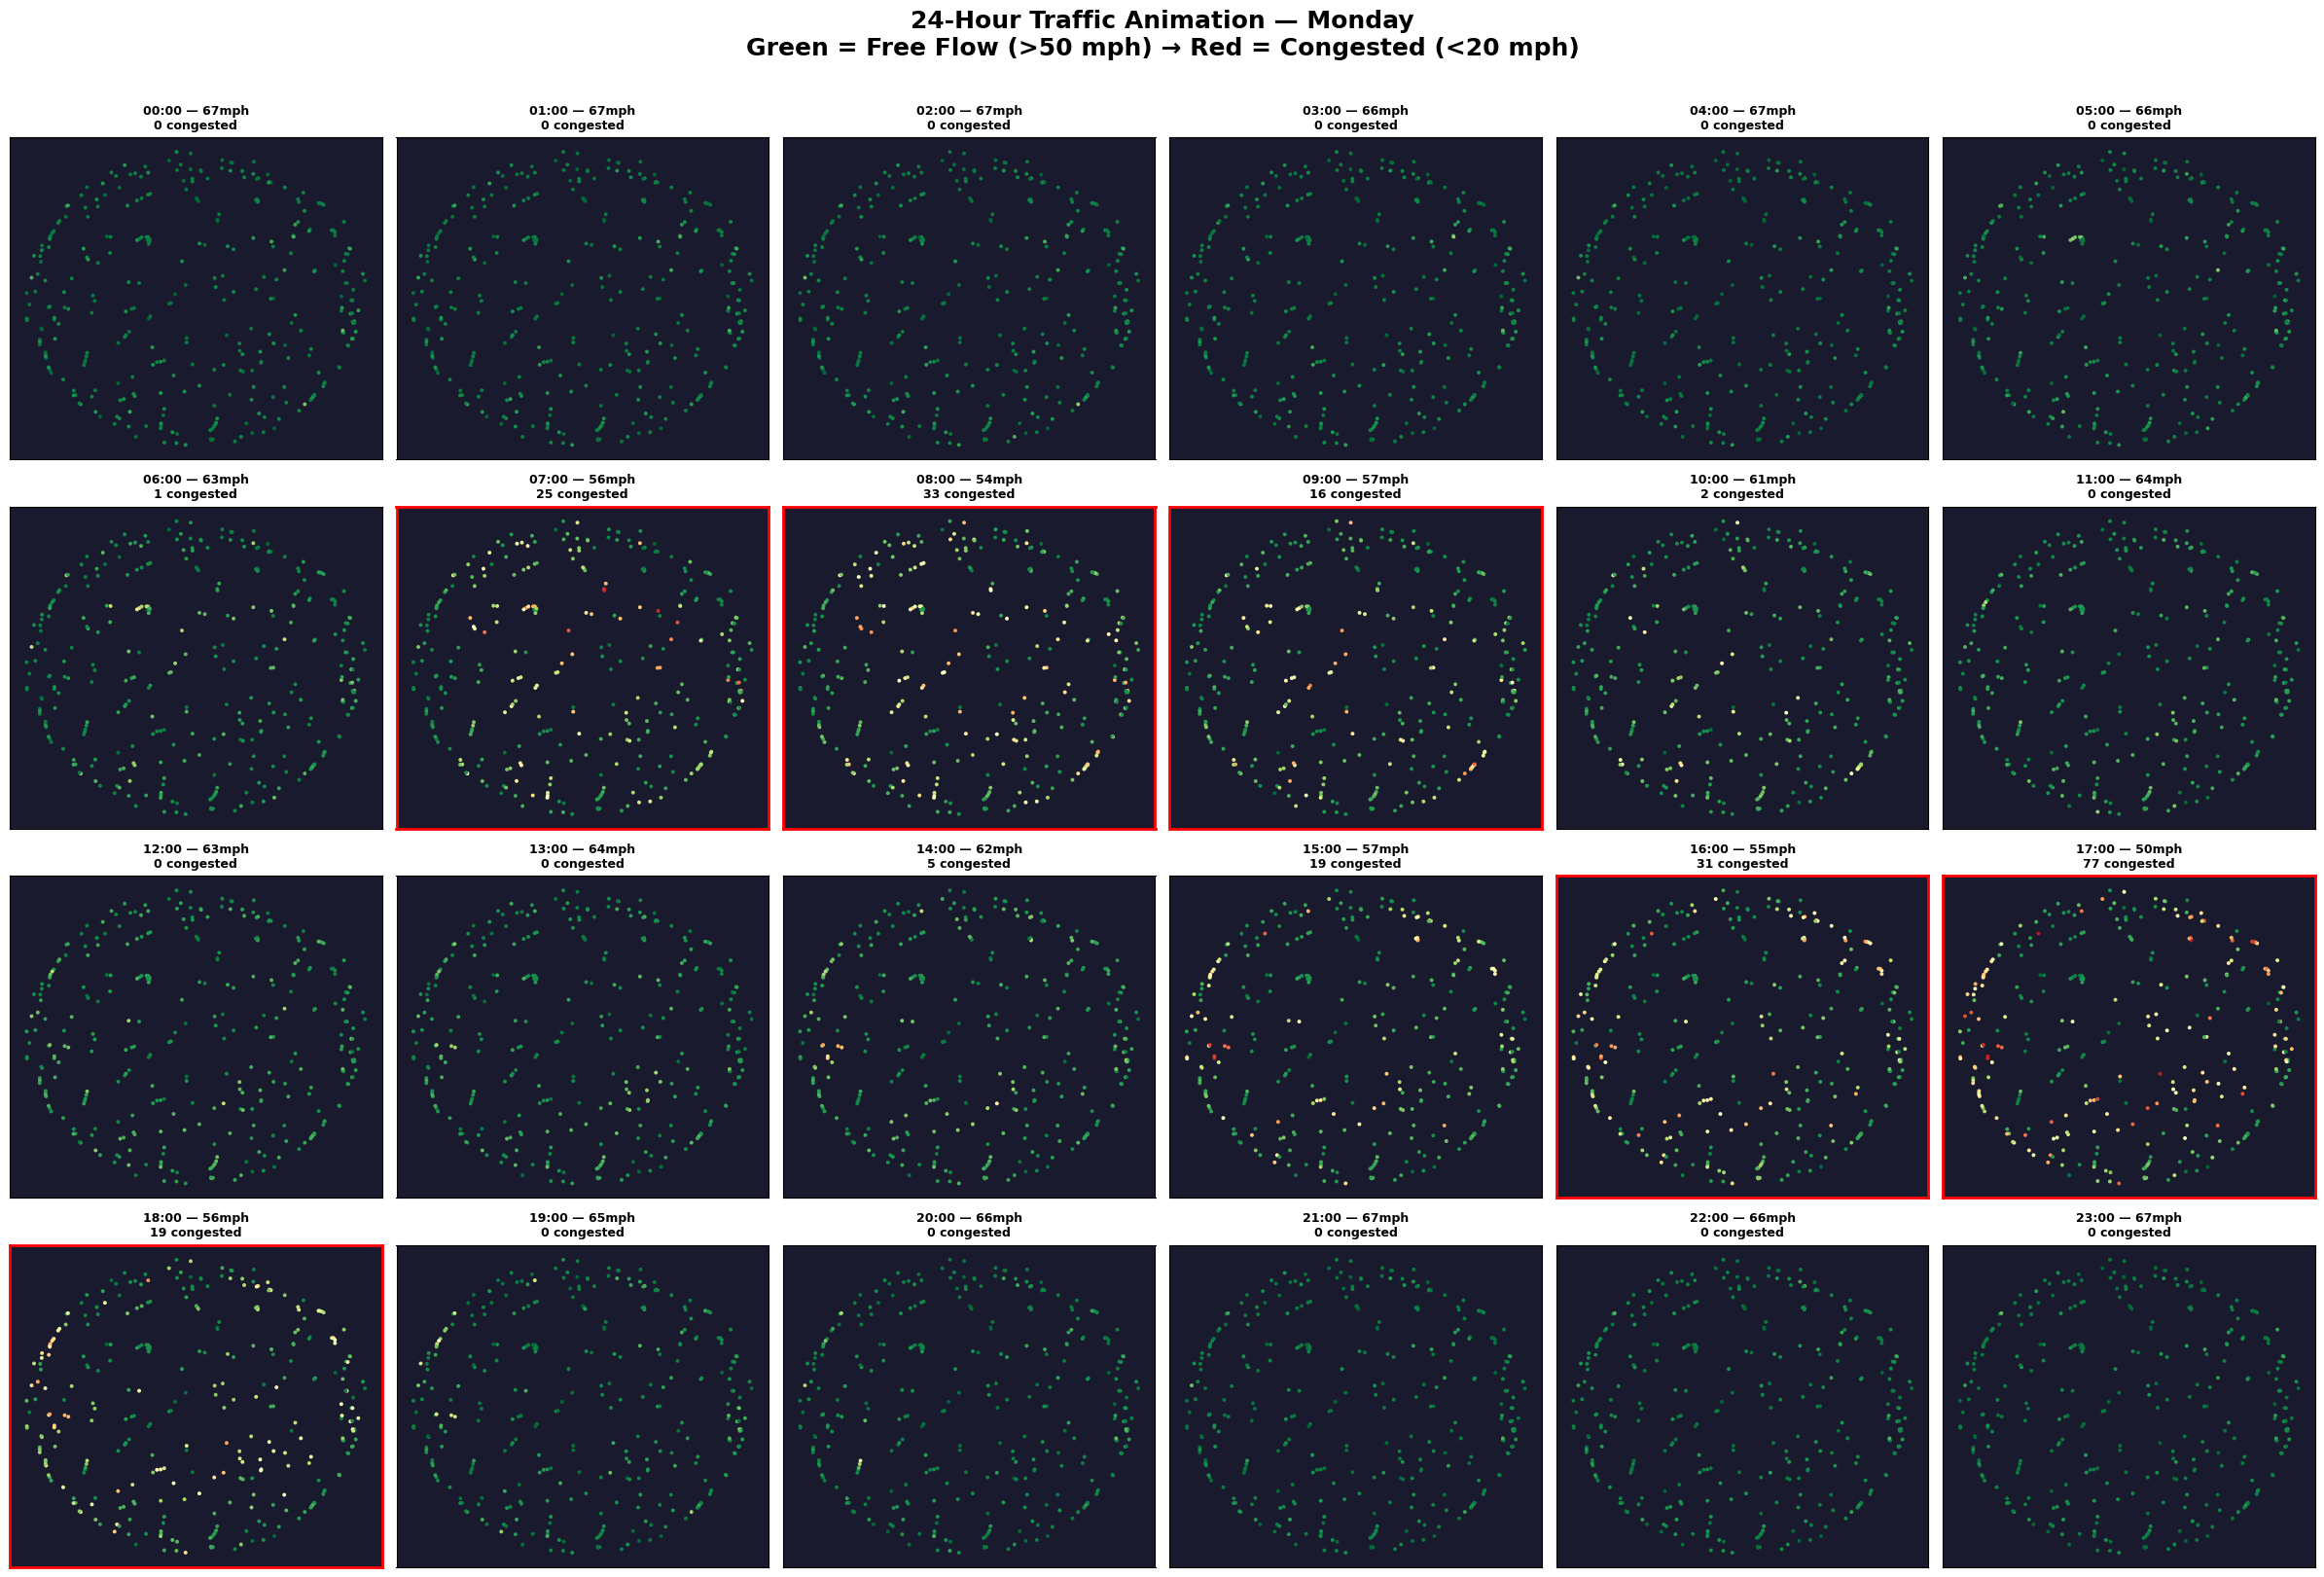

Red borders = rush hours (7-9 AM, 4-6 PM)


In [13]:
ANIM_DAY = 0  # Monday

fig, axes = plt.subplots(4, 6, figsize=(24, 16))
fig.suptitle(f'24-Hour Traffic Animation — {DAYS[ANIM_DAY]}\n'
             f'Green = Free Flow (>50 mph) → Red = Congested (<20 mph)',
             fontsize=18, fontweight='bold', y=1.01)

for hour in range(24):
    ax = axes[hour//6, hour%6]
    pred = predict_all_sensors(ANIM_DAY, hour)
    spd = pred[0]  # H1

    ax.scatter(lngs, lats, c=spd, cmap='RdYlGn', vmin=10, vmax=70,
              s=8, edgecolors='none')

    n_cong = (spd < 35).sum()
    ax.set_title(f'{hour:02d}:00 — {spd.mean():.0f}mph\n{n_cong} congested',
               fontsize=9, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_facecolor('#1a1a2e')

    # Red border for rush hours
    if hour in [7,8,9,16,17,18]:
        for spine in ax.spines.values(): spine.set_color('red'); spine.set_linewidth(2)

plt.tight_layout()
plt.savefig('map_24h_animation.png', dpi=200, bbox_inches='tight')
plt.show()
print('Red borders = rush hours (7-9 AM, 4-6 PM)')

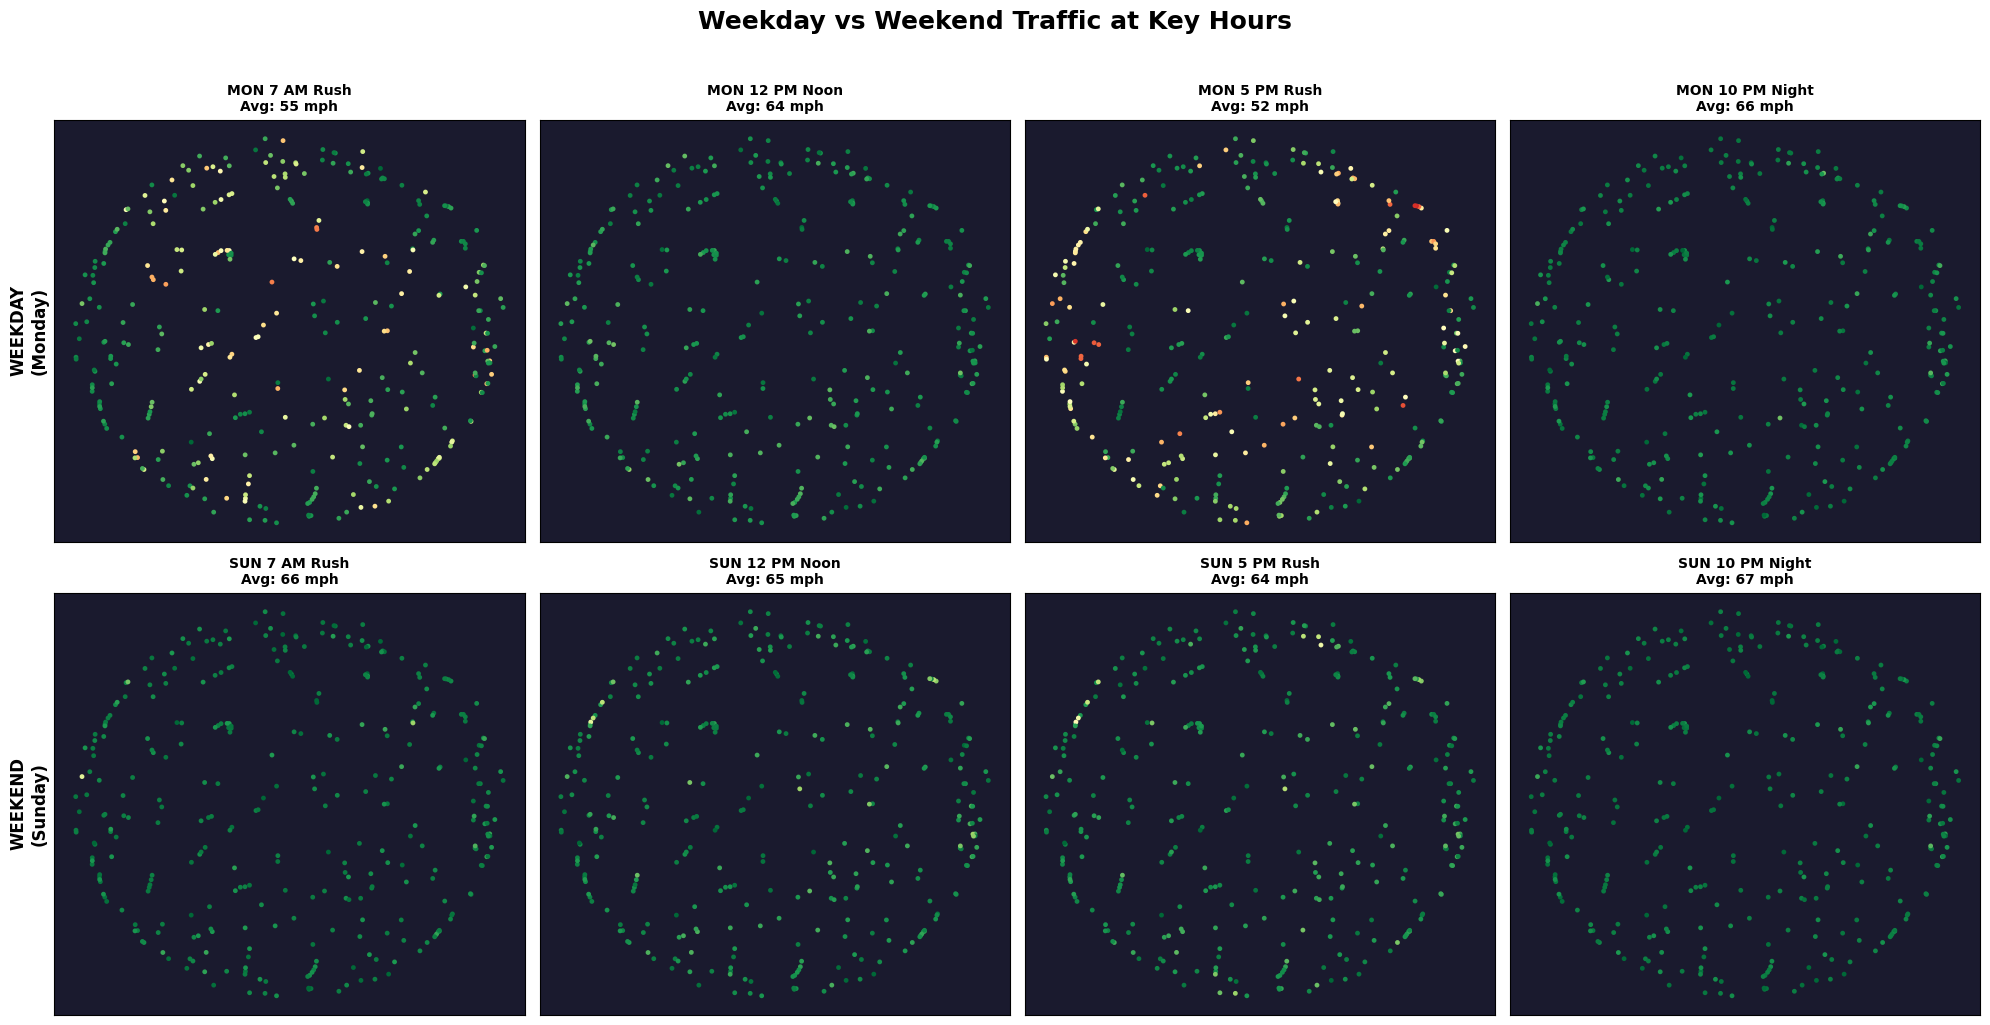

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Weekday vs Weekend Traffic at Key Hours', fontsize=18, fontweight='bold', y=1.02)

hours_show = [7, 12, 17, 22]  # morning rush, noon, evening rush, night
hour_labels = ['7 AM Rush', '12 PM Noon', '5 PM Rush', '10 PM Night']

for col, (hour, hlabel) in enumerate(zip(hours_show, hour_labels)):
    # Weekday (Monday)
    pred_wd = predict_all_sensors(0, hour)[0]
    axes[0, col].scatter(lngs, lats, c=pred_wd, cmap='RdYlGn', vmin=10, vmax=70, s=12, edgecolors='none')
    axes[0, col].set_title(f'MON {hlabel}\nAvg: {pred_wd.mean():.0f} mph', fontsize=10, fontweight='bold')
    axes[0, col].set_xticks([]); axes[0, col].set_yticks([]); axes[0, col].set_facecolor('#1a1a2e')

    # Weekend (Sunday)
    pred_we = predict_all_sensors(6, hour)[0]
    axes[1, col].scatter(lngs, lats, c=pred_we, cmap='RdYlGn', vmin=10, vmax=70, s=12, edgecolors='none')
    axes[1, col].set_title(f'SUN {hlabel}\nAvg: {pred_we.mean():.0f} mph', fontsize=10, fontweight='bold')
    axes[1, col].set_xticks([]); axes[1, col].set_yticks([]); axes[1, col].set_facecolor('#1a1a2e')

axes[0,0].set_ylabel('WEEKDAY\n(Monday)', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('WEEKEND\n(Sunday)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('map_weekday_vs_weekend.png', dpi=200, bbox_inches='tight')
plt.show()

In [15]:
import shutil
SAVE_DIR = os.path.join(DATA_DIR, 'results', 'map_figures')
os.makedirs(SAVE_DIR, exist_ok=True)
m.save(os.path.join(SAVE_DIR, 'interactive_traffic_map.html'))
for f in ['map_comparison.png','map_24h_animation.png','map_weekday_vs_weekend.png']:
    if os.path.exists(f): shutil.copy(f, os.path.join(SAVE_DIR, f))
print(f'All map visuals + interactive HTML saved to {SAVE_DIR}/')
print(f' Open interactive_traffic_map.html in a browser for the full experience!')

All map visuals + interactive HTML saved to /content/drive/MyDrive/LSTGAN_Data/results/map_figures/
 Open interactive_traffic_map.html in a browser for the full experience!
